# Первинний аналіз даних (EDA) датасету про оренду житла

### Завантаження даних та попередній аналіз

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

df = pd.read_csv('../data/raw/House_Rent_10M_balanced_40cities.csv')
print(df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 15 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Property ID        object
 1   Building Type      object
 2   Year Built         int64 
 3   Posted On          object
 4   BHK                int64 
 5   Rent               int64 
 6   Size               int64 
 7   Floor              object
 8   Area Type          object
 9   Area Locality      object
 10  City               object
 11  Furnishing Status  object
 12  Tenant Preferred   object
 13  Bathroom           int64 
 14  Point of Contact   object
dtypes: int64(5), object(10)
memory usage: 1.1+ GB
None


### Попередній feature engineering (видалення очевидно непотрібних ознак)

In [43]:
columns_to_drop = ['Property ID', 'Area Locality', 'Posted On']

df_cleaned = df.drop(columns=columns_to_drop)

print(f"Залишилося колонок: {df_cleaned.shape[1]}")
print(df_cleaned.columns)

Залишилося колонок: 12
Index(['Building Type', 'Year Built', 'BHK', 'Rent', 'Size', 'Floor',
       'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')


### Перевірка пропусків

In [44]:
# 1. Рахуємо кількість пропусків у кожній колонці
missing_values = df_cleaned.isnull().sum()

# 2. Рахуємо відсоток пропусків
missing_percentage = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

# 3. Об'єднуємо в одну таблицю для зручності
missing_df = pd.DataFrame({
    'Column': df_cleaned.columns,
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

print(missing_df)

                              Column  Missing Values  Percentage (%)
Building Type          Building Type               0             0.0
Year Built                Year Built               0             0.0
BHK                              BHK               0             0.0
Rent                            Rent               0             0.0
Size                            Size               0             0.0
Floor                          Floor               0             0.0
Area Type                  Area Type               0             0.0
City                            City               0             0.0
Furnishing Status  Furnishing Status               0             0.0
Tenant Preferred    Tenant Preferred               0             0.0
Bathroom                    Bathroom               0             0.0
Point of Contact    Point of Contact               0             0.0


### Створення нових ознак з ознаки Floor (нові ознаки - Floor_Number, Total_Floors)

In [45]:
split_floors = df_cleaned['Floor'].str.split(' out of ', expand=True)

floor_num = split_floors[0].str.strip().str.lower()

# Текстові значення та їх числові еквіваленти
floor_mapping = {
    'ground': 0,
    'upper basement': -1,
    'lower basement': -2,
    'basement': -1
}
floor_num = floor_num.replace(floor_mapping)

df_cleaned['Floor_Number'] = pd.to_numeric(floor_num, errors='coerce')

df_cleaned['Total_Floors'] = pd.to_numeric(split_floors[1], errors='coerce')

df_cleaned['Total_Floors'] = df_cleaned['Total_Floors'].fillna(df_cleaned['Floor_Number'])

df_cleaned['Floor_Number'] = df_cleaned['Floor_Number'].fillna(0)
df_cleaned['Total_Floors'] = df_cleaned['Total_Floors'].fillna(1)

columns_to_drop = ['Floor']
df_cleaned.drop(columns=columns_to_drop, inplace=True, errors='ignore')

In [46]:
missing_floors = df_cleaned[['Floor_Number', 'Total_Floors']].isnull().sum()
missing_floors_pct = (missing_floors / len(df_cleaned)) * 100

missing_summary = pd.DataFrame({
    'Пропуски (шт)': missing_floors,
    'Відсоток (%)': missing_floors_pct
})
print(missing_summary)

              Пропуски (шт)  Відсоток (%)
Floor_Number              0           0.0
Total_Floors              0           0.0


### Візуалізація розподілу цільової змінної 

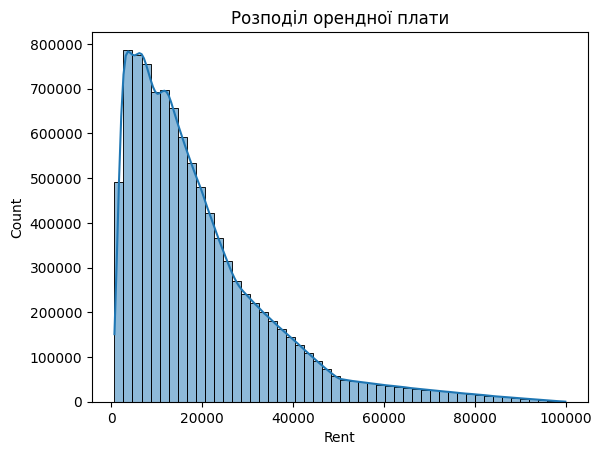

In [47]:
sns.histplot(df_cleaned['Rent'], bins=50, kde=True)
plt.title('Розподіл орендної плати')
plt.show()

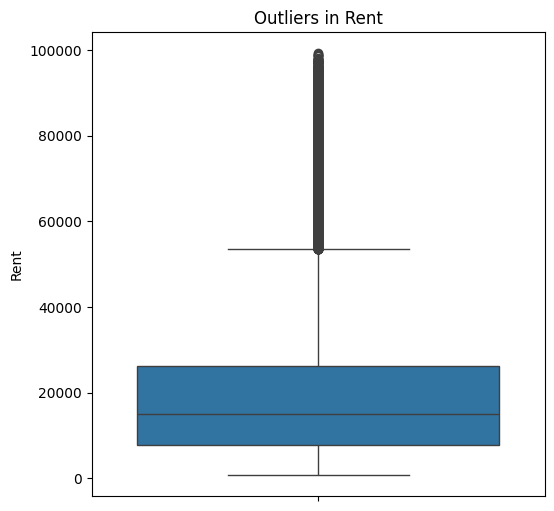

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Беремо 100,000 випадкових рядків для візуалізації
df_sample = df.sample(n=100000, random_state=42)

cols_to_check = ['Rent']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_sample[col])
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

### Очищення даних які знаходяться вище 99 перцентиля

In [49]:
rent_99th = df_cleaned['Rent'].quantile(0.99)
print(f"Межа 99-го перцентиля для Rent: {rent_99th:,.2f} рупій")

outliers_count = len(df_cleaned[df_cleaned['Rent'] > rent_99th])
print(f"Кількість об'єктів (аутлаєрів) до видалення: {outliers_count}")

df_cleaned = df_cleaned[df_cleaned['Rent'] <= rent_99th]

print(f"Розмір датасету після очищення: {len(df_cleaned)} рядків")

Межа 99-го перцентиля для Rent: 77,725.00 рупій
Кількість об'єктів (аутлаєрів) до видалення: 99997
Розмір датасету після очищення: 9900003 рядків


### Матриця кореляції

<Axes: >

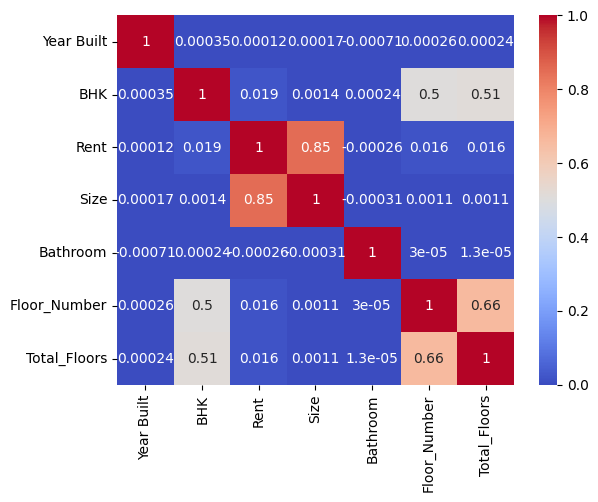

In [53]:
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap='coolwarm')

### Оцінка кількості унікальних значень в категоріальних ознаках

In [54]:
categorical_cols = ['Building Type', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(f"Кількість унікальних: {df_cleaned[col].nunique()}")
    print(df_cleaned[col].unique())
    print("\n")

--- Building Type ---
Кількість унікальних: 6
['Apartment' 'Single Family' 'Condo' 'House' 'Office' 'Land']


--- Area Type ---
Кількість унікальних: 4
['Built Area' 'Carpet Area' 'Plot Area' 'Super Area']


--- City ---
Кількість унікальних: 40
['Ghaziabad' 'Meerut' 'Vijayawada' 'Faridabad' 'Jodhpur' 'Coimbatore'
 'Aurangabad' 'Chandigarh' 'Mumbai' 'Patna' 'Ludhiana' 'Ranchi'
 'Ahmedabad' 'Noida' 'Lucknow' 'Bangalore' 'Kalyan-Dombivli' 'Rajkot'
 'Mysore' 'Mangalore' 'Gwalior' 'Hyderabad' 'Navi Mumbai' 'Kanpur' 'Delhi'
 'Nashik' 'Varanasi' 'Thane' 'Nagpur' 'Surat' 'Chennai' 'Pune' 'Vadodara'
 'Agra' 'Visakhapatnam' 'Amritsar' 'Kolkata' 'Jaipur' 'Bhopal' 'Indore']


--- Furnishing Status ---
Кількість унікальних: 3
['Furnished' 'Semi-Furnished' 'Unfurnished']


--- Tenant Preferred ---
Кількість унікальних: 3
['Bachelors' 'Family' 'Bachelors/Family']




### Збереження очищеного датасету

In [55]:
processed_path = '../data/raw/'

file_name = 'cleaned_house_rent_data.csv'
df_cleaned.to_csv(os.path.join(processed_path, file_name), index=False)
print(f"Очищений датасет збережено у: {processed_path}{file_name}")

Очищений датасет збережено у: ../data/raw/cleaned_house_rent_data.csv
